In [3]:
from data_meta_map.task2vec import task2vec
from data_meta_map.models import get_model
from data_meta_map import datasets
from data_meta_map.task2vec import plot_distance_matrix

In [4]:
dataset_names = ('mnist', 'cifar10', 'cifar100', 'letters')
dataset_list = [datasets.__dict__[name](root='../../data')[0] for name in dataset_names] 

Files already downloaded and verified
Files already downloaded and verified


In [5]:
embeddings = []
for name, dataset in zip(dataset_names, dataset_list):
    print(f"Embedding {name}")
    probe_network = get_model('resnet18', pretrained=True, num_classes=int(max(dataset.targets)+1)).cuda()
    embeddings.append(task2vec(probe_network, dataset, skip_layers=6, max_samples=1000))

Embedding mnist


Caching features:   0%|          | 0/14 [00:00<?, ?it/s]

Fitting classifier:   0%|          | 0/10 [00:00<?, ?it/s]

Computing Fisher:   0%|          | 0/156 [00:00<?, ?it/s]

Embedding cifar10


...

Computing Fisher:   0%|          | 0/156 [00:00<?, ?it/s]

Embedding letters


Caching features:   0%|          | 0/14 [00:00<?, ?it/s]

Fitting classifier:   0%|          | 0/10 [00:00<?, ?it/s]

Computing Fisher:   0%|          | 0/156 [00:00<?, ?it/s]

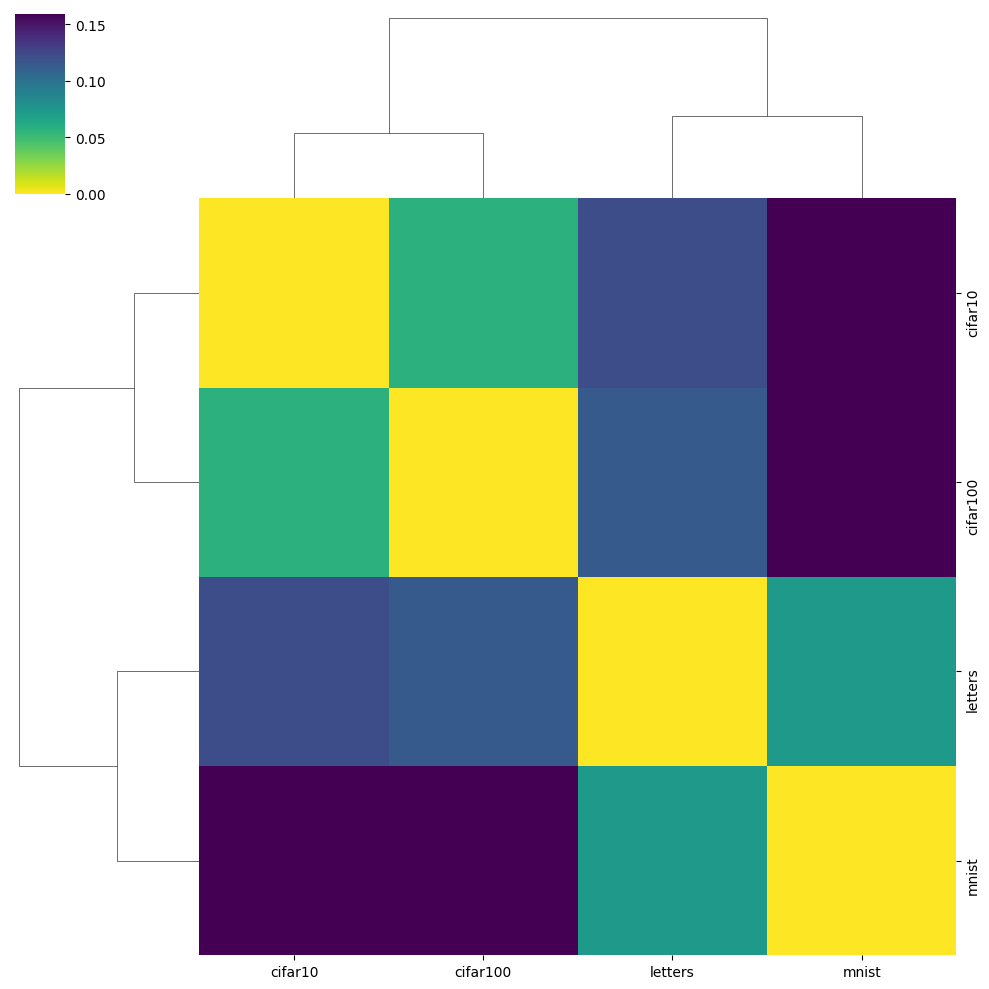

In [6]:
plot_distance_matrix(embeddings=embeddings, labels=dataset_names)